<a href="https://colab.research.google.com/github/tantienvo55/Ph-n-lo-i-c-m-x-c-v-n-b-n/blob/main/Ph%C3%A2n_lo%E1%BA%A1i_c%E1%BA%A3m_x%C3%BAc_v%C4%83n_b%E1%BA%A3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import re
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Embedding, GRU, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)

TensorFlow version: 2.20.0
GPU available: True


In [ ]:
VOCAB_SIZE = 20000
MAX_LENGTH = 200
TRAIN_SIZE = 20000
TEST_SIZE = 10000

raw_dataset = load_dataset("fancyzhx/yelp_polarity")

train_full = raw_dataset["train"].shuffle(seed=SEED)
test_full = raw_dataset["test"].shuffle(seed=SEED)

train_subset = train_full.select(range(TRAIN_SIZE))
test_subset = test_full.select(range(TEST_SIZE))

X_train_text = train_subset["text"]
y_train = np.array(train_subset["label"])

X_test_text = test_subset["text"]
y_test = np.array(test_subset["label"])

print("Số mẫu train dùng trong lab:", len(X_train_text))
print("Số mẫu test dùng trong lab:", len(X_test_text))
print("Ví dụ review đầu tiên:")
print(X_train_text[0][:300], "...")
print("Nhãn:", "Tích cực" if y_train[0] == 1 else "Tiêu cực")

Số mẫu train dùng trong lab: 20000
Số mẫu test dùng trong lab: 10000
Ví dụ review đầu tiên:
Decent size, decent selection, decent staff.\n\nI guess that can wholly sum this place up, it's decent.  As with many other stores that are like this, the product rotates depending on what doesn't sale well at other stores.  Can always snag a deal here.  I was able to pick up a pretty sweet Puma jac ...
Nhãn: Tích cực


In [ ]:
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

word_index = tokenizer.word_index
print("Kích thước vocabulary thực tế (bao gồm cả từ hiếm):", len(word_index))
print("Sequence đầu tiên (30 token đầu):")
print(X_train_seq[0][:30], "...")

Kích thước vocabulary thực tế (bao gồm cả từ hiếm): 46867
Sequence đầu tiên (30 token đầu):
[388, 535, 388, 340, 388, 133, 13, 86, 434, 14, 75, 12569, 1879, 17, 32, 47, 63, 388, 36, 20, 200, 81, 1118, 14, 29, 41, 17, 2, 1326, 12570] ...


In [ ]:
lengths_train = [len(seq) for seq in X_train_seq]
lengths_test = [len(seq) for seq in X_test_seq]

length_stats = pd.DataFrame({
    "tập_dữ_liệu": ["train", "test"],
    "số_mẫu": [len(lengths_train), len(lengths_test)],
    "độ_dài_trung_bình": [np.mean(lengths_train), np.mean(lengths_test)],
    "độ_dài_nhỏ_nhất": [np.min(lengths_train), np.min(lengths_test)],
    "độ_dài_lớn_nhất": [np.max(lengths_train), np.max(lengths_test)],
    "trung_vị": [np.median(lengths_train), np.median(lengths_test)],
})
length_stats.round(2)

,tập_dữ_liệu,số_mẫu,độ_dài_trung_bình,độ_dài_nhỏ_nhất,độ_dài_lớn_nhất,trung_vị
0,train,20000,135.69,1,1046,100.0
1,test,10000,133.46,1,1005,97.0


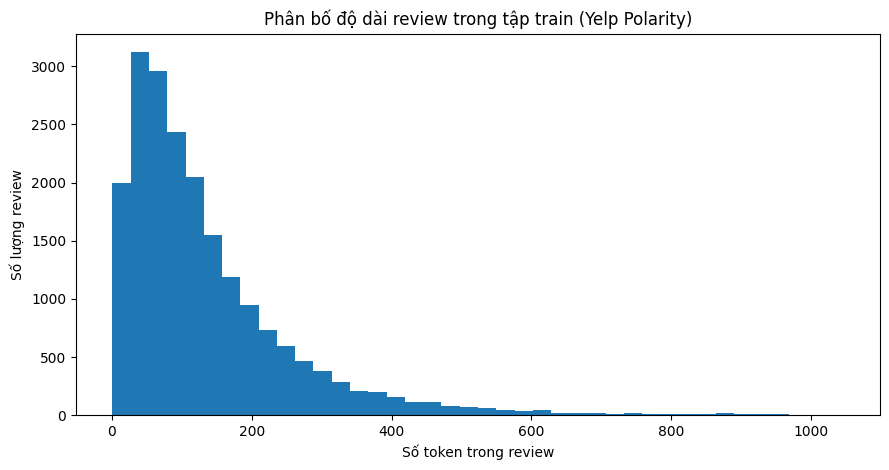

In [ ]:
plt.figure(figsize=(9, 4.8))
plt.hist(lengths_train, bins=40)
plt.title("Phân bố độ dài review trong tập train (Yelp Polarity)")
plt.xlabel("Số token trong review")
plt.ylabel("Số lượng review")
plt.tight_layout()
plt.show()

In [ ]:
X_train = pad_sequences(
    X_train_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)
X_test = pad_sequences(
    X_test_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("Shape X_train:", X_train.shape)
print("Shape y_train:", y_train.shape)
print("Shape X_test:", X_test.shape)
print("Shape y_test:", y_test.shape)

Shape X_train: (20000, 200)
Shape y_train: (20000,)
Shape X_test: (10000, 200)
Shape y_test: (10000,)


In [ ]:
EMBEDDING_DIM = 128
RNN_UNITS_1 = 128
RNN_UNITS_2 = 64

def build_sequence_model(model_type="gru"):
    inputs = Input(shape=(MAX_LENGTH,), dtype="int32", name="review_input")

    x = Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True,
        name=f"{model_type}_embedding"
    )(inputs)

    if model_type == "gru":
        x = GRU(
            RNN_UNITS_1,
            return_sequences=True,
            name="gru_layer_1"
        )(x)
        x = Dropout(0.3, name="dropout_after_gru_1")(x)
        x = GRU(
            RNN_UNITS_2,
            name="gru_layer_2"
        )(x)

    elif model_type == "bilstm":
        x = Bidirectional(
            LSTM(RNN_UNITS_1, return_sequences=True),
            name="bilstm_layer_1"
        )(x)
        x = Dropout(0.3, name="dropout_after_bilstm_1")(x)
        x = Bidirectional(
            LSTM(RNN_UNITS_2),
            name="bilstm_layer_2"
        )(x)

    else:
        raise ValueError("model_type phải là 'gru' hoặc 'bilstm'.")

    x = Dropout(0.3, name="dropout_before_output")(x)
    outputs = Dense(1, activation="sigmoid", name="sentiment_output")(x)

    model = Model(
        inputs=inputs,
        outputs=outputs,
        name=f"{model_type.upper()}_2Layer_Yelp_Sentiment"
    )

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

## Mô hình GRU

In [ ]:
gru_model = build_sequence_model(model_type="gru")
gru_model.summary()

Model: "GRU_2Layer_Yelp_Sentiment"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ review_input        │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_embedding       │ (None, 200, 128)  │  2,560,000 │ review_input[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_3         │ (None, 200)       │          0 │ review_input[0][… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_layer_1 (GRU)   │ (None, 200, 128)  │     99,072 │ gru_embedding[0]… │
│                     │                   │            │ not_equal_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_after_gru_1 │ (None, 200, 128)  │          0 │ gru_layer_1[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_layer_2 (GRU)   │ (None, 64)        │     37,248 │ dropout_after_gr… │
│                     │                   │            │ not_equal_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_before_out… │ (None, 64)        │          0 │ gru_layer_2[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentiment_output    │ (None, 1)         │         65 │ dropout_before_o… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,696,385 (10.29 MB)

 Trainable params: 2,696,385 (10.29 MB)

 Non-trainable params: 0 (0.00 B)

## Mô hình Bidirectional LSTM

In [ ]:
bilstm_model = build_sequence_model(model_type="bilstm")
bilstm_model.summary()

Model: "BILSTM_2Layer_Yelp_Sentiment"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ review_input        │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_embedding    │ (None, 200, 128)  │  2,560,000 │ review_input[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_4         │ (None, 200)       │          0 │ review_input[0][… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_layer_1      │ (None, 200, 256)  │    263,168 │ bilstm_embedding… │
│ (Bidirectional)     │                   │            │ not_equal_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_after_bils… │ (None, 200, 256)  │          0 │ bilstm_layer_1[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_layer_2      │ (None, 128)       │    164,352 │ dropout_after_bi… │
│ (Bidirectional)     │                   │            │ not_equal_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_before_out… │ (None, 128)       │          0 │ bilstm_layer_2[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentiment_output    │ (None, 1)         │        129 │ dropout_before_o… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,987,649 (11.40 MB)

 Trainable params: 2,987,649 (11.40 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 30
BATCH_SIZE = 128

def train_model(model, X_train, y_train):
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    start_time = time.time()
    history = model.fit(
        X_train,
        y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1
    )
    training_time = time.time() - start_time

    return history, training_time

In [ ]:
print("Huấn luyện mô hình GRU")
gru_history, gru_time = train_model(gru_model, X_train, y_train)
print("\nThời gian huấn luyện GRU:", round(gru_time, 2), "giây")

Huấn luyện mô hình GRU
Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.7529 - loss: 0.5001 - val_accuracy: 0.8725 - val_loss: 0.3140
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9125 - loss: 0.2306 - val_accuracy: 0.8915 - val_loss: 0.2730
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.9493 - loss: 0.1475 - val_accuracy: 0.8820 - val_loss: 0.3837
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9556 - loss: 0.1244 - val_accuracy: 0.8752 - val_loss: 0.4217
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9601 - loss: 0.1083 - val_accuracy: 0.8890 - val_loss: 0.3384

Thời gian huấn luyện GRU: 22.6 giây


In [ ]:
print("Huấn luyện mô hình Bidirectional LSTM")
bilstm_history, bilstm_time = train_model(bilstm_model, X_train, y_train)
print("\nThời gian huấn luyện BiLSTM:", round(bilstm_time, 2), "giây")

Huấn luyện mô hình Bidirectional LSTM
Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.8280 - loss: 0.3772 - val_accuracy: 0.9025 - val_loss: 0.2425
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - accuracy: 0.9382 - loss: 0.1618 - val_accuracy: 0.8898 - val_loss: 0.3187
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - accuracy: 0.9631 - loss: 0.1044 - val_accuracy: 0.8827 - val_loss: 0.3031
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.9667 - loss: 0.0939 - val_accuracy: 0.8568 - val_loss: 0.4287

Thời gian huấn luyện BiLSTM: 32.65 giây


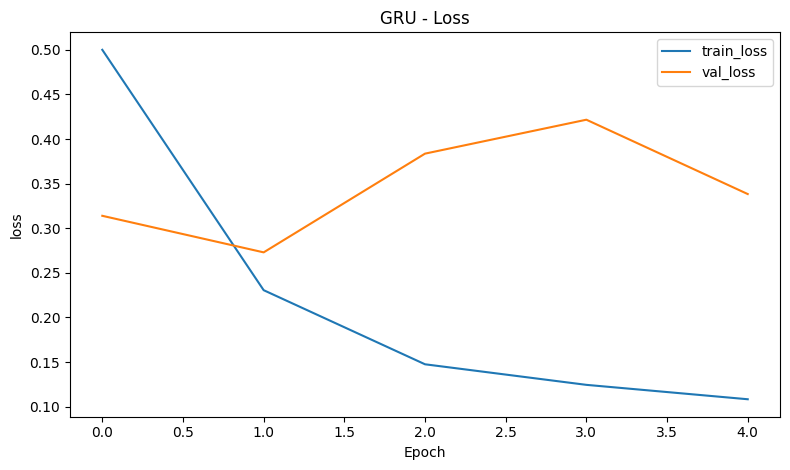

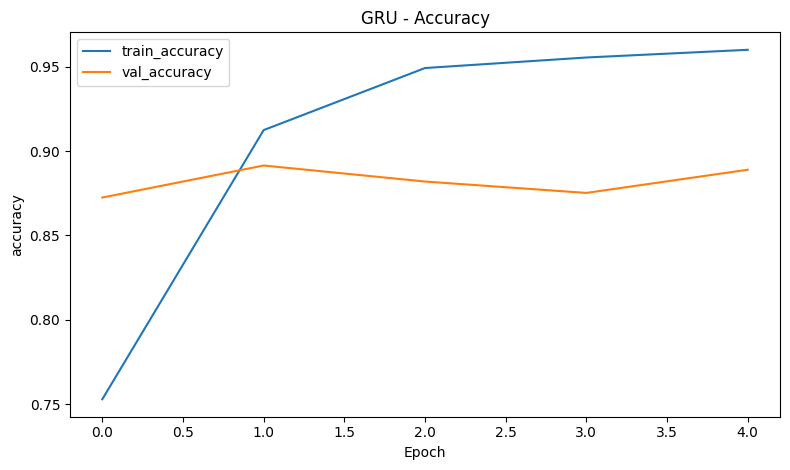

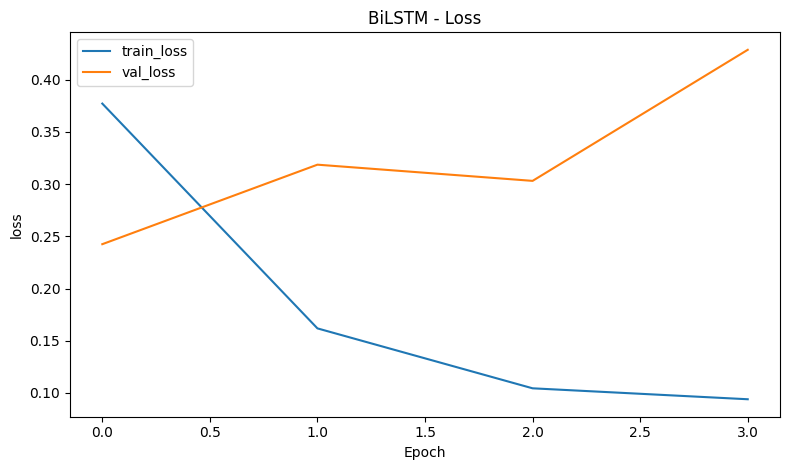

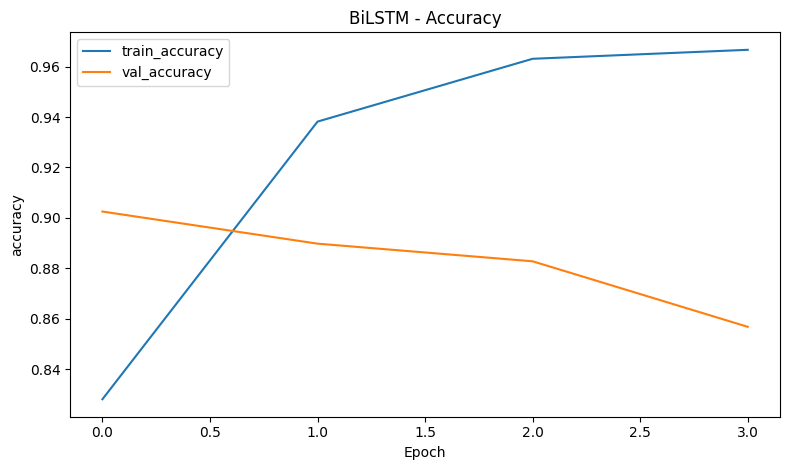

In [ ]:
def plot_metric(history, metric, title):
    plt.figure(figsize=(8, 4.8))
    plt.plot(history.history[metric], label=f"train_{metric}")
    plt.plot(history.history[f"val_{metric}"], label=f"val_{metric}")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_metric(gru_history, "loss", "GRU - Loss")
plot_metric(gru_history, "accuracy", "GRU - Accuracy")
plot_metric(bilstm_history, "loss", "BiLSTM - Loss")
plot_metric(bilstm_history, "accuracy", "BiLSTM - Accuracy")

In [ ]:
def classification_report_binary(model, X, y, threshold=0.5):
    probabilities = model.predict(X, batch_size=256, verbose=0).reshape(-1)
    predictions = (probabilities >= threshold).astype(int)

    tp = int(np.sum((predictions == 1) & (y == 1)))
    tn = int(np.sum((predictions == 0) & (y == 0)))
    fp = int(np.sum((predictions == 1) & (y == 0)))
    fn = int(np.sum((predictions == 0) & (y == 1)))

    accuracy = (tp + tn) / len(y)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
    }

gru_report = classification_report_binary(gru_model, X_test, y_test)
bilstm_report = classification_report_binary(bilstm_model, X_test, y_test)

pd.DataFrame([
    {
        "model": "GRU",
        "params": gru_model.count_params(),
        "training_time_seconds": gru_time,
        **gru_report,
    },
    {
        "model": "BiLSTM",
        "params": bilstm_model.count_params(),
        "training_time_seconds": bilstm_time,
        **bilstm_report,
    }
]).round(4)

,model,params,training_time_seconds,accuracy,precision,recall,f1_score,tp,tn,fp,fn
0,GRU,2696385,22.5990,0.8977,0.8749,0.9274,0.9004,4622,4355,661,362
1,BiLSTM,2987649,32.6532,0.9071,0.9041,0.9101,0.9071,4536,4535,481,448


In [ ]:
def confusion_matrix_dataframe(report):
    return pd.DataFrame(
        [
            [report["tn"], report["fp"]],
            [report["fn"], report["tp"]],
        ],
        index=["Thực tế tiêu cực", "Thực tế tích cực"],
        columns=["Dự đoán tiêu cực", "Dự đoán tích cực"]
    )

print("Confusion matrix - GRU")
display(confusion_matrix_dataframe(gru_report))

print("Confusion matrix - BiLSTM")
display(confusion_matrix_dataframe(bilstm_report))

Confusion matrix - GRU


,Dự đoán tiêu cực,Dự đoán tích cực
Thực tế tiêu cực,4355,661
Thực tế tích cực,362,4622


Confusion matrix - BiLSTM


,Dự đoán tiêu cực,Dự đoán tích cực
Thực tế tiêu cực,4535,481
Thực tế tích cực,448,4536


In [ ]:
def predict_review_sentiment(text):
    sequence = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(sequence, maxlen=MAX_LENGTH, padding="post", truncating="post")

    gru_prob = float(gru_model.predict(padded, verbose=0)[0][0])
    bilstm_prob = float(bilstm_model.predict(padded, verbose=0)[0][0])

    return {
        "review": text,
        "sequence_20_tokens_đầu": sequence[0][:20],
        "gru_positive_probability": gru_prob,
        "gru_label": "positive" if gru_prob >= 0.5 else "negative",
        "bilstm_positive_probability": bilstm_prob,
        "bilstm_label": "positive" if bilstm_prob >= 0.5 else "negative",
    }

new_reviews = [
    "The food was amazing and the service was excellent",
    "Terrible experience, the staff was rude and the place was dirty",
    "Decent food but the wait time was way too long",
    "I will definitely come back, best restaurant in town",
    "Not worth the price, very disappointed with the quality",
]

prediction_rows = [predict_review_sentiment(review) for review in new_reviews]
pd.DataFrame(prediction_rows)

,review,sequence_20_tokens_đầu,gru_positive_probability,gru_label,bilstm_positive_probability,bilstm_label
0,The food was amazing and the service was excel...,"[2, 30, 7, 205, 3, 2, 52, 7, 357]",0.947831,positive,0.969965,positive
1,"Terrible experience, the staff was rude and th...","[446, 141, 2, 133, 7, 385, 3, 2, 32, 7, 655]",0.014030,negative,0.009309,negative
2,Decent food but the wait time was way too long,"[388, 30, 18, 2, 153, 48, 7, 120, 88, 191]",0.302196,negative,0.208650,negative
3,"I will definitely come back, best restaurant i...","[4, 70, 170, 125, 57, 110, 105, 10, 365]",0.952255,positive,0.980874,positive
4,"Not worth the price, very disappointed with th...","[23, 223, 2, 190, 43, 353, 20, 2, 243]",0.153002,negative,0.074907,negative
